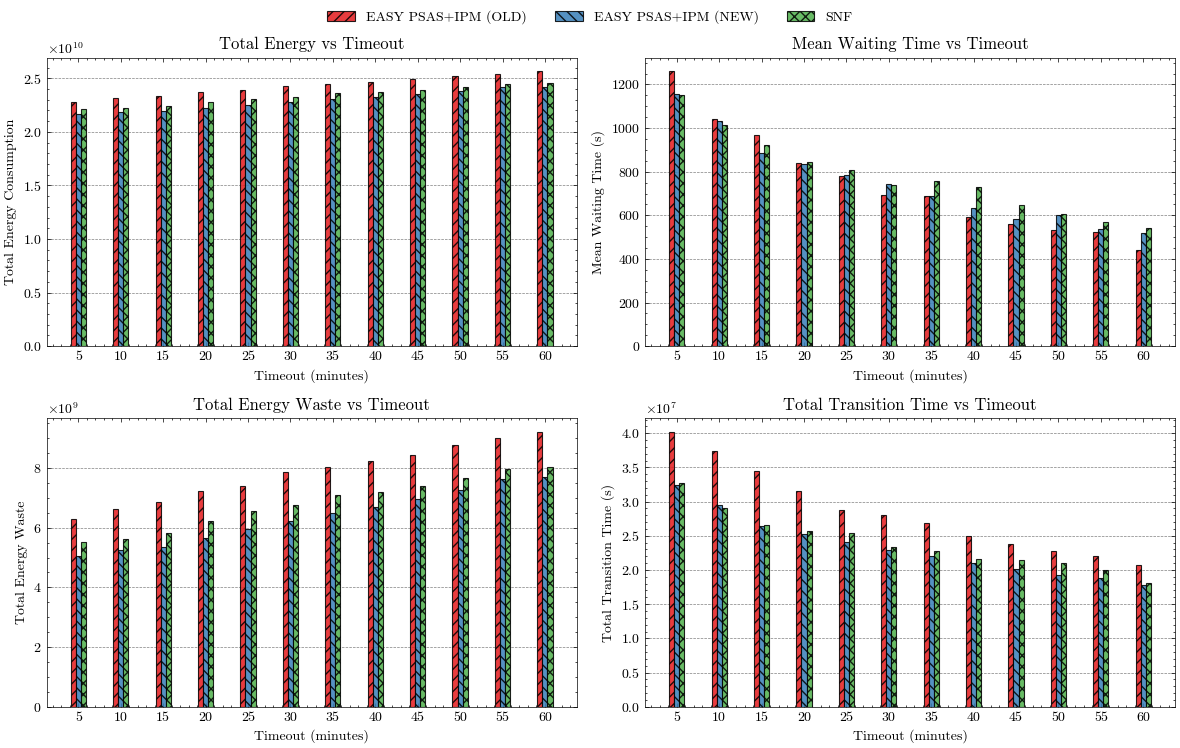


=== COMPARING ALL ALGORITHMS ===

EASY PSAS+IPM (OLD) vs EASY PSAS+IPM (NEW):
  Energy Difference: 6.05%
  Waiting Time Difference: 5.58%
  Energy Waste Difference: 23.55%
  Transition Time Difference: 21.71%

EASY PSAS+IPM (OLD) vs SNF:
  Energy Difference: 4.03%
  Waiting Time Difference: 8.99%
  Energy Waste Difference: 14.84%
  Transition Time Difference: 17.99%

EASY PSAS+IPM (NEW) vs SNF:
  Energy Difference: 1.91%
  Waiting Time Difference: 4.44%
  Energy Waste Difference: 7.01%
  Transition Time Difference: 3.31%


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

plt.style.use(['science', 'no-latex', 'grid'])

# --- Config ---
workload_name = "nasa_20_back"

# Create output plot directory
plot_dir = os.path.join("plots", workload_name)
os.makedirs(plot_dir, exist_ok=True)

timeouts = [300, 600, 900, 1200, 1500, 1800,
            2100, 2400, 2700, 3000, 3300, 3600]

# === Algorithm configuration ===
algo_config = {
    "EASY PSAS+IPM (OLD)": ("results_save", "easy_psas"),
    "EASY PSAS+IPM (NEW)": ("results", "easy_psas"),
    "SJF": ("results_v2", "sjf_psas"),
}

display_labels = list(algo_config.keys())
algo_dirs = {label: config[0] for label, config in algo_config.items()}
algo_names = {label: config[1] for label, config in algo_config.items()}

# --- Load metrics ---
total_energy_consumption = {label: [] for label in display_labels}
mean_waiting_time = {label: [] for label in display_labels}
total_energy_waste = {label: [] for label in display_labels}
total_transition_time = {label: [] for label in display_labels}

for t in timeouts:
    for label in display_labels:
        base_dir = algo_dirs[label]
        algo_name = algo_names[label]
        
        metrics_path = os.path.join(
            base_dir,
            f"{workload_name}_timeout_{t}_{algo_name}",
            "metrics.csv"
        )

        if not os.path.exists(metrics_path):
            print(f"⚠️ Warning: missing {metrics_path}")
            total_energy_consumption[label].append(float("nan"))
            mean_waiting_time[label].append(float("nan"))
            total_energy_waste[label].append(float("nan"))
            total_transition_time[label].append(float("nan"))
            continue

        df = pd.read_csv(metrics_path)
        row = df.iloc[0]

        # total energy
        if "total_energy_consumption" in df.columns:
            tew = row["total_energy_consumption"]
        elif "consumed_joules" in df.columns:
            tew = row["consumed_joules"]
        else:
            print(f"⚠️ No energy column in {metrics_path}")
            tew = float("nan")

        # total energy waste (if available)
        if "total_energy_waste" in df.columns:
            waste = row["total_energy_waste"]
        elif "wasted_joules" in df.columns:
            waste = row["wasted_joules"]
        elif "energy_waste" in df.columns:
            waste = row["energy_waste"]
        else:
            waste = float("nan")

        # total transition time (switching_off + switching_on)
        switching_off = row.get("total_switching_off", 0)
        switching_on = row.get("total_switching_on", 0)
        transition = switching_off + switching_on

        total_energy_consumption[label].append(tew)
        mean_waiting_time[label].append(row["mean_waiting_time"])
        total_energy_waste[label].append(waste)
        total_transition_time[label].append(transition)

# --- Prepare plotting parameters ---
timeouts_minutes = [t // 60 for t in timeouts]
x = range(len(timeouts))
bar_width = 0.12
n_algos = len(display_labels)

colors = ['#e41a1c', '#377eb8', '#4daf4a',
          '#984ea3', '#ff7f00', '#ffff33', '#a65628']
hatches = ['///', '\\\\\\', 'xxx', '---', '+++', '...', '**']

# === 2x2 Grid Plot ===
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
ax1, ax2, ax3, ax4 = axs[0, 0], axs[0, 1], axs[1, 0], axs[1, 1]

for i, label in enumerate(display_labels):
    positions = [xi + (i - n_algos / 2) * bar_width + bar_width / 2 for xi in x]

    # Subplot 1: Total Energy (Top Left)
    ax1.bar(
        positions,
        total_energy_consumption[label],
        width=bar_width,
        label=label,
        color=colors[i % len(colors)],
        hatch=hatches[i % len(hatches)],
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )

    # Subplot 2: Mean Waiting Time (Top Right)
    ax2.bar(
        positions,
        mean_waiting_time[label],
        width=bar_width,
        color=colors[i % len(colors)],
        hatch=hatches[i % len(hatches)],
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )

    # Subplot 3: Total Energy Waste (Bottom Left)
    ax3.bar(
        positions,
        total_energy_waste[label],
        width=bar_width,
        color=colors[i % len(colors)],
        hatch=hatches[i % len(hatches)],
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )

    # Subplot 4: Total Transition Time (Bottom Right)
    ax4.bar(
        positions,
        total_transition_time[label],
        width=bar_width,
        color=colors[i % len(colors)],
        hatch=hatches[i % len(hatches)],
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )

# X ticks & labels for all subplots
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xticks(list(x))
    ax.set_xticklabels(timeouts_minutes)
    ax.set_xlabel("Timeout (minutes)")
    ax.grid(False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

# Y labels
ax1.set_ylabel("Total Energy Consumption")
ax2.set_ylabel("Mean Waiting Time (s)")
ax3.set_ylabel("Total Energy Waste")
ax4.set_ylabel("Total Transition Time (s)")

# Titles
ax1.set_title("Total Energy vs Timeout")
ax2.set_title("Mean Waiting Time vs Timeout")
ax3.set_title("Total Energy Waste vs Timeout")
ax4.set_title("Total Transition Time vs Timeout")

# Single legend for all plots
handles, labels_legend = ax1.get_legend_handles_labels()
fig.legend(
    handles,
    labels_legend,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.95),
    ncol=min(len(display_labels), 4),
    frameon=False
)

fig.tight_layout(rect=[0, 0, 1, 0.92])

# Save combined figure
combined_name = f"{workload_name}_energy_wait_waste_transition_vs_timeout_2x2"
fig.savefig(
    os.path.join(plot_dir, combined_name + ".png"),
    dpi=1000,
    bbox_inches="tight"
)
fig.savefig(
    os.path.join(plot_dir, combined_name + ".pdf"),
    dpi=1000,
    bbox_inches="tight"
)

plt.show()

# === Compare all algorithms ===
print("\n=== COMPARING ALL ALGORITHMS ===")
for i in range(len(display_labels)):
    for j in range(i + 1, len(display_labels)):
        algo1 = display_labels[i]
        algo2 = display_labels[j]
        
        energy_diffs = []
        wait_diffs = []
        waste_diffs = []
        transition_diffs = []
        
        for k in range(len(timeouts)):
            val1 = total_energy_consumption[algo1][k]
            val2 = total_energy_consumption[algo2][k]
            mw1 = mean_waiting_time[algo1][k]
            mw2 = mean_waiting_time[algo2][k]
            waste1 = total_energy_waste[algo1][k]
            waste2 = total_energy_waste[algo2][k]
            trans1 = total_transition_time[algo1][k]
            trans2 = total_transition_time[algo2][k]
            
            if not pd.isna(val1) and not pd.isna(val2) and val2 != 0:
                energy_diffs.append(abs(val1 - val2) / val2)
            
            if not pd.isna(mw1) and not pd.isna(mw2) and mw2 != 0:
                wait_diffs.append(abs(mw1 - mw2) / mw2)
            
            if not pd.isna(waste1) and not pd.isna(waste2) and waste2 != 0:
                waste_diffs.append(abs(waste1 - waste2) / waste2)
            
            if not pd.isna(trans1) and not pd.isna(trans2) and trans2 != 0:
                transition_diffs.append(abs(trans1 - trans2) / trans2)
        
        print(f"\n{algo1} vs {algo2}:")
        if energy_diffs:
            avg_energy_diff = np.mean(energy_diffs) * 100
            print(f"  Energy Difference: {avg_energy_diff:.2f}%")
        else:
            print(f"  Energy: No valid data")
        
        if wait_diffs:
            avg_wait_diff = np.mean(wait_diffs) * 100
            print(f"  Waiting Time Difference: {avg_wait_diff:.2f}%")
        else:
            print(f"  Waiting Time: No valid data")
        
        if waste_diffs:
            avg_waste_diff = np.mean(waste_diffs) * 100
            print(f"  Energy Waste Difference: {avg_waste_diff:.2f}%")
        else:
            print(f"  Energy Waste: No valid data")
        
        if transition_diffs:
            avg_transition_diff = np.mean(transition_diffs) * 100
            print(f"  Transition Time Difference: {avg_transition_diff:.2f}%")
        else:
            print(f"  Transition Time: No valid data")